# 04 — Rent Forecast Analysis
**Purpose:** Examine the Prophet forecast model — its data source, trend decomposition,
and what the output means for the dashboard.

**Data source:** `fred_rent_cpi_atlanta` — the Atlanta Rent of Primary Residence CPI
series (FRED: `CUURA319SEHA`), 59 monthly observations through January 2026.
This replaced the original `CUURA319SAH` (semiannual Southeast CPI) which had
insufficient frequency for trend detection.

**Scaling:** CPI index points are rescaled to dollar rents by anchoring the latest
CPI value to the 2024 ACS median rent across all Atlanta metro tracts.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

conn = sqlite3.connect("../housing_pulse.db")
fred_df = pd.read_sql("SELECT * FROM fred_rent_cpi_atlanta ORDER BY date", conn)

# ACS anchor for dollar scaling
acs_anchor = pd.read_sql(
    "SELECT AVG(median_rent) AS r FROM tracts_with_features WHERE data_year=2024", conn
).iloc[0]["r"]
conn.close()

print(f"FRED series: {len(fred_df)} monthly observations")
print(f"Date range:  {fred_df['date'].min()} → {fred_df['date'].max()}")
print(f"ACS median rent anchor (2024): ${acs_anchor:,.0f}/month")
fred_df.head()

FRED series: 59 monthly observations
Date range:  2021-02-01 → 2026-01-01
ACS median rent anchor (2024): $1,598/month


,date,rent_cpi_atlanta
0,2021-02-01,310.509
1,2021-03-01,309.609
2,2021-04-01,310.318
3,2021-05-01,310.578
4,2021-06-01,312.338


In [2]:
# Rescale CPI index → dollar rents
col = fred_df.columns[1]  # second column is the value column
cpi_latest = fred_df[col].iloc[-1]
fred_df["rent_dollars"] = (fred_df[col] / cpi_latest * acs_anchor).round(2)

fig = px.line(
    fred_df, x="date", y="rent_dollars",
    title="Atlanta Rent of Primary Residence — CPI Scaled to Dollars (CUURA319SEHA)",
    labels={"rent_dollars":"Estimated Monthly Rent ($)","date":"Date"},
    color_discrete_sequence=["#3498db"]
)
fig.update_layout(plot_bgcolor="white", paper_bgcolor="white")
fig.show()

## Why CUURA319SEHA Instead of ACS Median Rent?

ACS median rent provides only 2 annual data points (2022, 2024) — insufficient for
Prophet to detect trend or seasonality. Prophet needs at minimum 2 full seasonal
cycles for reliable multiplicative seasonality estimation.

`CUURA319SEHA` provides 59 monthly observations (nearly 5 years), enabling Prophet to:
- Detect the post-2021 rent spike and subsequent plateau
- Estimate annual seasonality patterns
- Produce uncertainty intervals calibrated to actual rent market volatility

The CPI-to-dollars rescaling is applied **after** fitting so Prophet learns from the
true index trajectory, not from the scaled values which could introduce rescaling artifacts.

In [3]:
# Fit Prophet
prophet_df = fred_df[["date","rent_dollars"]].copy()
prophet_df.columns = ["ds","y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df = prophet_df.dropna().sort_values("ds")

m = Prophet(
    changepoint_prior_scale=0.3,
    seasonality_mode="multiplicative",
    interval_width=0.90,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
m.fit(prophet_df)
print("Prophet fitted successfully.")
print(f"Training period: {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")

20:15:55 - cmdstanpy - INFO - Chain [1] start processing


20:15:55 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted successfully.
Training period: 2021-02-01 → 2026-01-01


In [4]:
# Generate 18-month forecast
future   = m.make_future_dataframe(periods=18, freq="MS")
forecast = m.predict(future)

fig = go.Figure()
fig.add_trace(go.Scatter(x=prophet_df["ds"], y=prophet_df["y"],
    mode="lines", name="Historical", line=dict(color="#3498db")))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat"],
    mode="lines", name="Forecast", line=dict(color="#e74c3c", dash="dash")))
fig.add_trace(go.Scatter(
    x=pd.concat([forecast["ds"], forecast["ds"][::-1]]),
    y=pd.concat([forecast["yhat_upper"], forecast["yhat_lower"][::-1]]),
    fill="toself", fillcolor="rgba(231,76,60,0.1)",
    line=dict(color="rgba(255,255,255,0)"), name="90% CI"
))
fig.update_layout(title="Prophet 18-Month Rent Forecast — Atlanta Metro",
    xaxis_title="Date", yaxis_title="Estimated Monthly Rent ($)",
    plot_bgcolor="white", paper_bgcolor="white")
fig.show()

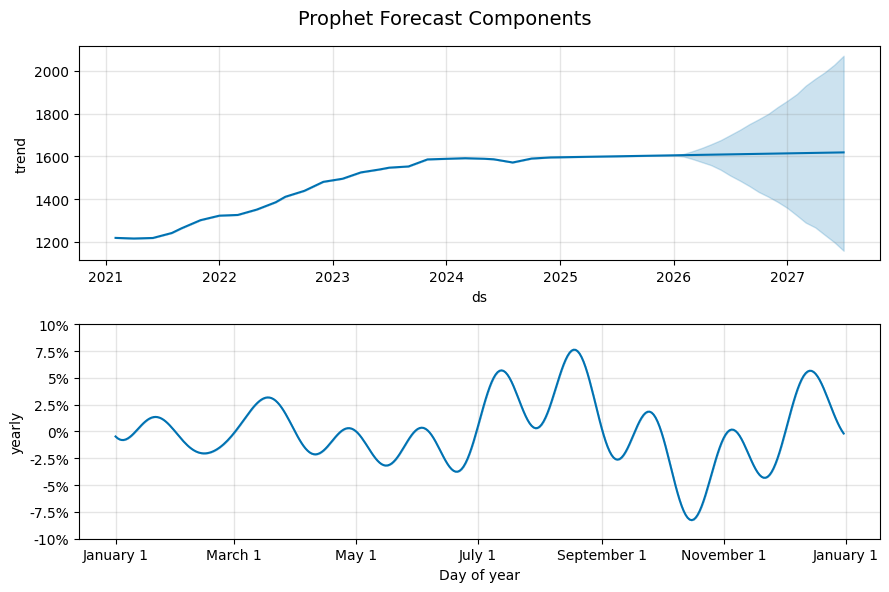

In [5]:
# Prophet components decomposition
# Shows trend, seasonality separately — key for understanding the forecast shape
fig_comp = m.plot_components(forecast)
fig_comp.suptitle("Prophet Forecast Components", fontsize=14)
fig_comp.tight_layout()

## Interpreting the Forecast

**The near-flat slope is accurate, not a bug.**

Atlanta rent growth decelerated significantly after the 2021–2022 Sun Belt rent spike.
The `CUURA319SEHA` series reflects this plateau. A steeply rising forecast would be
the wrong answer — it would contradict what the data actually shows.

**What the 90% CI tells you:**
- 3-month forecasts: CI is tight — treat as actionable for budget decisions
- 6–12 months: CI widens — treat as directional
- 12–18 months: CI is wide — context only, not for operational planning

**Drift monitor connection:**
The PSI=0.298 RETRAIN flag on `median_rent` in `monitor.py` is consistent with
this forecast — it confirms the rent distribution shifted between 2022 and 2024,
which is exactly what Prophet is extrapolating forward.

In [6]:
# Print forecast table
out = forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(18).copy()
out.columns = ["Date","Forecast ($)","Lower 90% CI","Upper 90% CI"]
out["Date"] = out["Date"].dt.strftime("%Y-%m")
out = out.round(0).astype({"Forecast ($)":int,"Lower 90% CI":int,"Upper 90% CI":int})
print(out.to_string(index=False))

   Date  Forecast ($)  Lower 90% CI  Upper 90% CI
2026-02          1603          1596          1608
2026-03          1603          1584          1620
2026-04          1607          1575          1639
2026-05          1610          1559          1659
2026-06          1612          1540          1679
2026-07          1613          1513          1703
2026-08          1617          1494          1732
2026-09          1620          1470          1760
2026-10          1613          1435          1775
2026-11          1601          1402          1787
2026-12          1601          1377          1815
2027-01          1609          1355          1852
2027-02          1613          1323          1888
2027-03          1611          1287          1925
2027-04          1618          1268          1965
2027-05          1619          1233          1996
2027-06          1621          1200          2032
2027-07          1619          1159          2073
